# Data Mining MBGAna-Analisis Clustering Prioritas Distribusi

Proyek ini menganalisis prioritas distribusi program Makan Bergizi Gratis (MBG) berdasarkan data stunting dan kemiskinan per provinsi di Indonesia menggunakan teknik clustering K-Means.

## 1. Impor Library

Impor pustaka yang diperlukan untuk analisis data, clustering, dan visualisasi.

In [39]:
# Impor library yang diperlukan
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur gaya visualisasi
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 2. Dataset

Membuat dataframe dengan data 38 provinsi Indonesia, termasuk prevalensi stunting, persentase kemiskinan, dan jumlah dapur SPPG MBG.

In [40]:
# Membuat dataframe dengan data provinsi Indonesia dari file CSV
# Load data stunting
stunting_df = pd.read_csv('data/vertikalkementerian-2-od_20953_prevalensi_balita_stunting_brdsrkn_prov_di_indones_v1_data.csv')
stunting_2024 = stunting_df[stunting_df['tahun'] == 2024][['nama_provinsi', 'prevalensi_balita_stunting']]
stunting_2024 = stunting_2024.rename(columns={'nama_provinsi': 'provinsi', 'prevalensi_balita_stunting': 'stunting_pct'})

# Bersihkan nama provinsi
stunting_2024['provinsi'] = stunting_2024['provinsi'].str.upper().str.replace(' ', '')

# Load data kemiskinan tingkat provinsi (perbaikan agregasi)
kemiskinan_df = pd.read_csv('data/Persentase Penduduk Miskin (P0) Menurut Kabupaten_Kota, 2025.csv', header=None, names=['daerah', 'nilai'])
kemiskinan_df = kemiskinan_df.iloc[3:].copy()  # lewati baris header tidak standar
kemiskinan_df['daerah'] = kemiskinan_df['daerah'].astype(str).str.strip()
kemiskinan_df['nilai'] = pd.to_numeric(kemiskinan_df['nilai'], errors='coerce')

provinsi_list = []
values = []
for _, row in kemiskinan_df.iterrows():
    daerah = row['daerah']
    nilai = row['nilai']
    if pd.isna(daerah):
        continue
    # Baris dengan huruf kapital semua adalah data provinsi
    if daerah == daerah.upper() and pd.notna(nilai):
        provinsi_list.append(daerah)
        values.append(nilai)

kemiskinan_prov = pd.DataFrame({'provinsi': provinsi_list, 'kemiskinan_pct': values})
# Perbaiki nama KEP. BANGKA BELITUNG agar cocok dengan data stunting
kemiskinan_prov['provinsi'] = kemiskinan_prov['provinsi'].str.upper().str.replace('KEP.', 'KEPULAUAN').str.replace(' ', '')

# Load data jumlah SPPG dari file CSV
sppg_df = pd.read_csv('data/rekap_bgn_sppg.csv')
sppg_df['provinsi'] = sppg_df['provinsi'].str.upper().str.replace(' ', '')
sppg_df = sppg_df[['provinsi', 'jumlahsppg']].rename(columns={'jumlahsppg': 'jumlah_sppg'})

# Merge semua sumber data
df = pd.merge(stunting_2024, kemiskinan_prov, on='provinsi', how='inner')
df = pd.merge(df, sppg_df, on='provinsi', how='inner')

print("Dataset berhasil dibuat dari file CSV:")
print(df.head()) 
print(df.tail()) 
print(f"\nUkuran dataset: {df.shape}")


Dataset berhasil dibuat dari file CSV:
        provinsi  stunting_pct  kemiskinan_pct  jumlah_sppg
0           ACEH          28.6           12.33          702
1  SUMATERAUTARA          22.0            7.36         1394
2  SUMATERABARAT          24.9            5.35          422
3           RIAU          20.1            6.16          951
4          JAMBI          17.1            7.19          211
           provinsi  stunting_pct  kemiskinan_pct  jumlah_sppg
33   PAPUABARATDAYA          30.5           17.95           33
34            PAPUA          24.7           19.16          149
35     PAPUASELATAN          25.7           19.71           19
36      PAPUATENGAH          24.7           28.90           34
37  PAPUAPEGUNUNGAN          24.7           30.03           13

Ukuran dataset: (38, 4)


## 3. Preprocessing

Melakukan pemeriksaan missing value dan normalisasi fitur menggunakan MinMaxScaler.

In [41]:
# Cek missing value
print("Cek missing value:")
print(df.isnull().sum())

# Normalisasi fitur menggunakan MinMaxScaler
scaler = MinMaxScaler()
features = ['stunting_pct', 'kemiskinan_pct', 'jumlah_sppg']
df_scaled = df.copy()
df_scaled[features] = scaler.fit_transform(df[features])

# Inverse nilai jumlah_sppg agar prioritas linier (jumlah sppg sedikit = prioritas tinggi)
df_scaled['jumlah_sppg'] = 1 - df_scaled['jumlah_sppg']

print("\nData setelah normalisasi (inverse SPPG):")
print(df_scaled[features].head())


Cek missing value:
provinsi          0
stunting_pct      0
kemiskinan_pct    0
jumlah_sppg       0
dtype: int64

Data setelah normalisasi (inverse SPPG):
   stunting_pct  kemiskinan_pct  jumlah_sppg
0      0.704225        0.327252     0.888801
1      0.471831        0.138350     0.779186
2      0.573944        0.061954     0.933154
3      0.404930        0.092740     0.849358
4      0.299296        0.131889     0.966577


## 4. Clustering

Melakukan clustering menggunakan K-Means dengan K=3 dan memberikan label prioritas berdasarkan rata-rata stunting dan kemiskinan.

In [42]:
# Clustering dengan K-Means (K=3)
kmeans = KMeans(n_clusters=3, random_state=42)
df_scaled['cluster'] = kmeans.fit_predict(df_scaled[features])

# Hitung rata-rata stunting, kemiskinan, dan inverse SPPG per cluster
cluster_means = df_scaled.groupby('cluster')[features].mean()
cluster_means['total_mean'] = cluster_means.sum(axis=1)

# Urutkan cluster berdasarkan total_mean descending
sorted_clusters = cluster_means.sort_values('total_mean', ascending=False).index

# Map cluster ke label prioritas
cluster_labels = {}
for i, cluster in enumerate(sorted_clusters):
    if i == 0:
        cluster_labels[cluster] = 'Prioritas Tinggi'
    elif i == 1:
        cluster_labels[cluster] = 'Prioritas Sedang'
    else:
        cluster_labels[cluster] = 'Prioritas Rendah'

df_scaled['prioritas'] = df_scaled['cluster'].map(cluster_labels)
# Terapkan juga ke df asli untuk visualisasi dan ekspor
df['cluster'] = df_scaled['cluster']
df['prioritas'] = df_scaled['prioritas']

print("Hasil clustering:")
print(df[['provinsi', 'cluster', 'prioritas']].head(10))


Hasil clustering:
                  provinsi  cluster         prioritas
0                     ACEH        1  Prioritas Tinggi
1            SUMATERAUTARA        2  Prioritas Sedang
2            SUMATERABARAT        2  Prioritas Sedang
3                     RIAU        2  Prioritas Sedang
4                    JAMBI        2  Prioritas Sedang
5          SUMATERASELATAN        2  Prioritas Sedang
6                 BENGKULU        2  Prioritas Sedang
7                  LAMPUNG        2  Prioritas Sedang
8  KEPULAUANBANGKABELITUNG        2  Prioritas Sedang
9            KEPULAUANRIAU        2  Prioritas Sedang


## 5. Visualisasi

Membuat tiga plot: scatter plot stunting vs kemiskinan, bar chart jumlah provinsi per cluster, dan heatmap rata-rata per cluster.

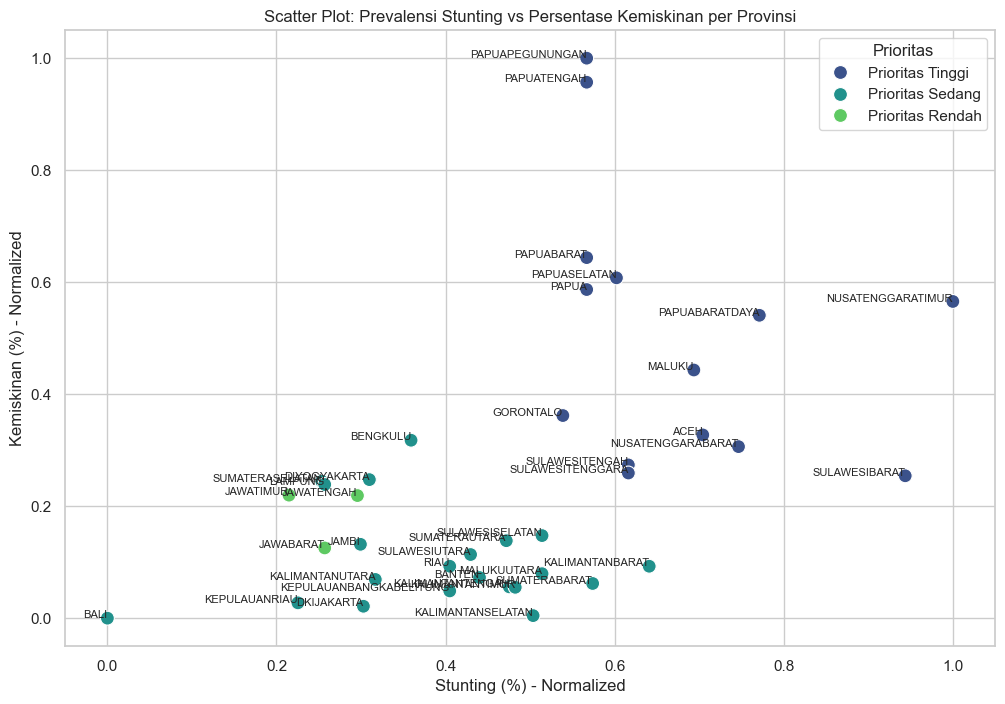

C:\Users\adity\AppData\Local\Temp\ipykernel_20820\1466291325.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette='viridis')


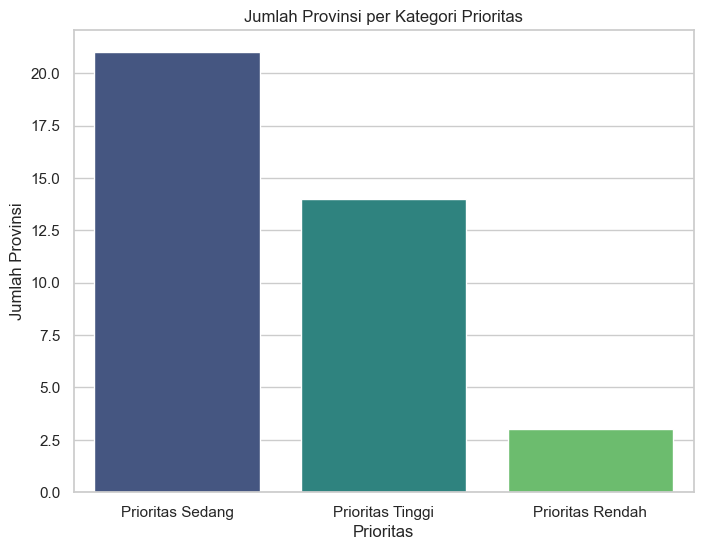

C:\Users\adity\AppData\Local\Temp\ipykernel_20820\1466291325.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, x='score', y='provinsi', palette='viridis')


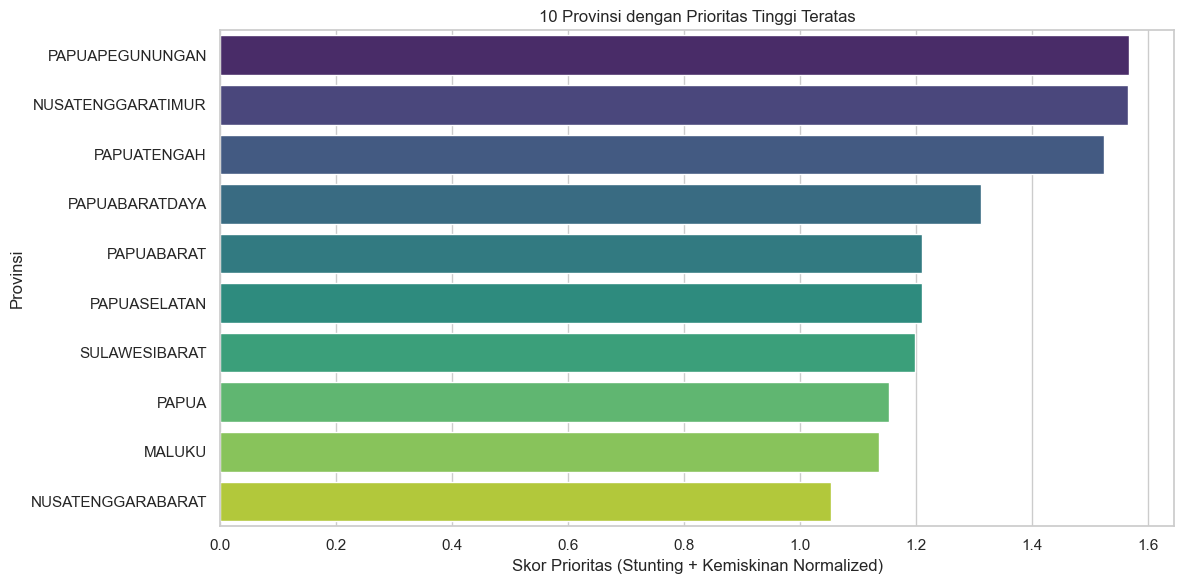

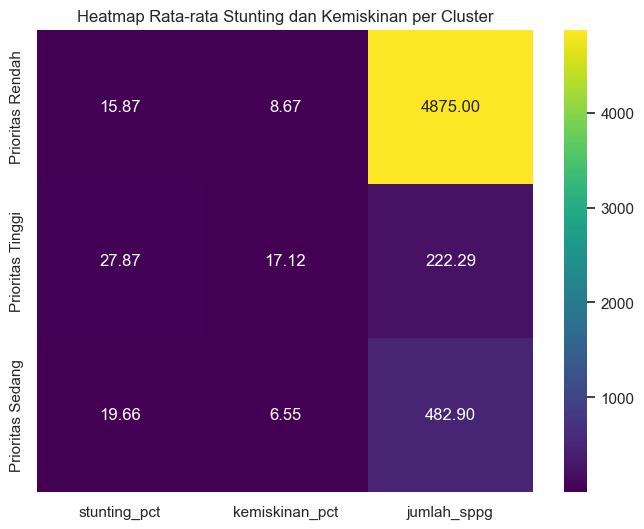

In [43]:
# 1. Scatter plot stunting vs kemiskinan
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_scaled, x='stunting_pct', y='kemiskinan_pct', hue='prioritas', palette='viridis', s=100)
for i, row in df_scaled.iterrows():
    plt.text(row['stunting_pct'], row['kemiskinan_pct'], row['provinsi'], fontsize=8, ha='right')
plt.title('Scatter Plot: Prevalensi Stunting vs Persentase Kemiskinan per Provinsi')
plt.xlabel('Stunting (%) - Normalized')
plt.ylabel('Kemiskinan (%) - Normalized')
plt.legend(title='Prioritas')
plt.show()

# 2. Bar chart jumlah provinsi per cluster
plt.figure(figsize=(8, 6))
cluster_counts = df_scaled['prioritas'].value_counts()
sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette='viridis')
plt.title('Jumlah Provinsi per Kategori Prioritas')
plt.xlabel('Prioritas')
plt.ylabel('Jumlah Provinsi')
plt.show()

# 2b. Bar chart 10 provinsi yang mendapat prioritas tertinggi
priority_scores = df_scaled.copy()
priority_scores['score'] = priority_scores['stunting_pct'] + priority_scores['kemiskinan_pct']
top10 = priority_scores[priority_scores['prioritas'] == 'Prioritas Tinggi'].nlargest(10, 'score')

plt.figure(figsize=(12, 6))
sns.barplot(data=top10, x='score', y='provinsi', palette='viridis')
plt.title('10 Provinsi dengan Prioritas Tinggi Teratas')
plt.xlabel('Skor Prioritas (Stunting + Kemiskinan Normalized)')
plt.ylabel('Provinsi')
plt.tight_layout()
plt.show()

# 3. Heatmap rata-rata per cluster
plt.figure(figsize=(8, 6))
cluster_means_original = df.groupby(df_scaled['cluster'])[features].mean()
cluster_means_original.index = [cluster_labels[c] for c in cluster_means_original.index]
sns.heatmap(cluster_means_original, annot=True, cmap='viridis', fmt='.2f')
plt.title('Heatmap Rata-rata Stunting dan Kemiskinan per Cluster')
plt.show()

## 6. Output Tabel Akhir

Menampilkan tabel akhir dengan provinsi, stunting, kemiskinan, sppg, dan prioritas, diurutkan dari prioritas tertinggi.

In [44]:
# Tabel akhir diurutkan berdasarkan prioritas (Tinggi -> Sedang -> Rendah)
priority_order = {'Prioritas Tinggi': 0, 'Prioritas Sedang': 1, 'Prioritas Rendah': 2}
df_final = df_scaled.sort_values(by='prioritas', key=lambda x: x.map(priority_order))

print("Tabel Akhir: Prioritas Distribusi MBG per Provinsi")
print(df_final[['provinsi', 'stunting_pct', 'kemiskinan_pct', 'jumlah_sppg', 'prioritas']].to_string(index=False))

Tabel Akhir: Prioritas Distribusi MBG per Provinsi
               provinsi  stunting_pct  kemiskinan_pct  jumlah_sppg        prioritas
                   ACEH      0.704225        0.327252     0.888801 Prioritas Tinggi
         SULAWESITENGAH      0.616197        0.273660     0.963884 Prioritas Tinggi
          SULAWESIBARAT      0.943662        0.254276     0.971487 Prioritas Tinggi
              GORONTALO      0.538732        0.361840     0.985585 Prioritas Tinggi
                 MALUKU      0.693662        0.443177     0.965626 Prioritas Tinggi
       SULAWESITENGGARA      0.616197        0.259217     0.956439 Prioritas Tinggi
      NUSATENGGARATIMUR      1.000000        0.565564     0.956597 Prioritas Tinggi
      NUSATENGGARABARAT      0.746479        0.306347     0.870901 Prioritas Tinggi
           PAPUASELATAN      0.602113        0.607754     0.996990 Prioritas Tinggi
                  PAPUA      0.566901        0.586849     0.976398 Prioritas Tinggi
        PAPUAPEGUNUNGAN  

## 7. Simpan Hasil

Menyimpan tabel akhir ke file CSV untuk penggunaan selanjutnya.

In [45]:
# Tabel akhir diurutkan berdasarkan prioritas (Tinggi -> Sedang -> Rendah)
priority_order = {'Prioritas Tinggi': 0, 'Prioritas Sedang': 1, 'Prioritas Rendah': 2}
df_final = df.sort_values(by='prioritas', key=lambda x: x.map(priority_order))

print("Tabel Akhir: Prioritas Distribusi MBG per Provinsi")
print(df_final[['provinsi', 'stunting_pct', 'kemiskinan_pct', 'jumlah_sppg', 'prioritas']].to_string(index=False))

# Simpan tabel akhir ke CSV menggunakan nilai aslinya
df_final[['provinsi', 'stunting_pct', 'kemiskinan_pct', 'jumlah_sppg', 'prioritas']].to_csv('hasil_prioritas_mbg.csv', index=False)
print("\nHasil telah disimpan ke 'hasil_prioritas_mbg.csv'")


Tabel Akhir: Prioritas Distribusi MBG per Provinsi
               provinsi  stunting_pct  kemiskinan_pct  jumlah_sppg        prioritas
                   ACEH          28.6           12.33          702 Prioritas Tinggi
         SULAWESITENGAH          26.1           10.92          228 Prioritas Tinggi
          SULAWESIBARAT          35.4           10.41          180 Prioritas Tinggi
              GORONTALO          23.9           13.24           91 Prioritas Tinggi
                 MALUKU          28.3           15.38          217 Prioritas Tinggi
       SULAWESITENGGARA          26.1           10.54          275 Prioritas Tinggi
      NUSATENGGARATIMUR          37.0           18.60          274 Prioritas Tinggi
      NUSATENGGARABARAT          29.8           11.78          815 Prioritas Tinggi
           PAPUASELATAN          25.7           19.71           19 Prioritas Tinggi
                  PAPUA          24.7           19.16          149 Prioritas Tinggi
        PAPUAPEGUNUNGAN  